# HealeyKahana2014 WeirdCMR Dual-Cue Parameter Shifting


Compare retrieval dynamics across global cue sensitivities.


This notebook combines the Healey & Kahana (2014) study configuration with the dual-cue dependent stop variant of the weird CMR model. It loads (or fits) the reference parameter set, then sweeps a chosen parameter to generate simulations for comparison analyses. Use it as a launch point for deeper parameter exploration and figure production.


In [1]:

%load_ext autoreload
%autoreload 2

import json
import os
import warnings

import jax.numpy as jnp
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.fitting import ScipyDE as fitting_method
from jaxcmr.helpers import (
    find_project_root,
    format_floats,
    generate_trial_mask,
    import_from_string,
    load_data,
)
from jaxcmr.math import cosine_similarity_matrix, lb, power_scale
from jaxcmr.simulation import (
    parameter_shifted_simulate_h5_from_h5,
)
from jaxcmr.simulation import (
    simulate_study_free_recall_and_forced_stop as simulate_trial_fn,
)
from jaxcmr.summarize import summarize_parameters
from jaxcmr.transform_likelihood import (
    ExcludeTerminationLikelihoodFnGenerator as loss_fn_generator,
)

warnings.filterwarnings("ignore")


## Setup


In [2]:

# Parameters

# Data parameters
base_data_tag = "HealeyKahana2014"
data_tag = "HealeyKahana2014"
data_path = "data/HealeyKahana2014.h5"
embedding_path = "data/florida_nouns-all-mpnet-base-v2.npy"
trial_query = "data['listtype'] == -1"

# Run configuration
run_tag = "fixed_term_best_of_3"
seed = 0
target_dir = "projects/HealeyKahana2014"
experiment_count = 5

# Flow toggles
allow_repeated_recalls = False
filter_repeated_recalls = True
handle_elis = False
redo_fits = False
redo_sims = False
redo_figures = True

# Model configuration
model_name = "WeirdCMRDualCueNoStop"
model_factory_path = "jaxcmr.models.weird_cmr_dual_cue_no_stop.BaseCMRFactory"

# Fitting hyperparameters
relative_tolerance = 0.001
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = 0.85
best_of = 3

# Parameter bounds
parameters = {
    "fixed": {},
    "free": {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
        "global_mcf_sensitivity": [2.220446049250313e-16, 3.0],
    },
}

# Analyses to generate
comparison_analysis_paths = [
    "jaxcmr.analyses.first_item_recall.plot_simple_first_item_recall_curve",
    "jaxcmr.analyses.spc.plot_spc",
    "jaxcmr.analyses.crp.plot_crp",
    "jaxcmr.analyses.pnr.plot_pnr",
]

# Parameter sweep configuration
varied_parameter = "global_mcf_sensitivity"

In [4]:
# Prepare directories and baseline objects
product_dirs = {}
for product in ["fits", "figures", "simulations"]:
    product_dir = os.path.join(target_dir, product)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

max_size = np.max(data["pres_itemnos"])
embeddings = embeddings = np.load(
    os.path.join(find_project_root(), embedding_path)
).astype(np.float32)
connections = cosine_similarity_matrix(embeddings)
distances = 1 - connections

comparison_analyses = [import_from_string(path) for path in comparison_analysis_paths]
model_factory = import_from_string(model_factory_path)
BaseCMR = import_from_string(model_factory_path[:model_factory_path.rfind(".")]+".BaseCMR")

parameters["fixed"]["allow_repeated_recalls"] = allow_repeated_recalls
query_parameters = list(parameters["free"].keys())

if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )


## Fitting


In [5]:
fit_path = os.path.join(product_dirs["fits"], f"{data_tag}_{model_name}_{run_tag}.json")
print(fit_path)

if os.path.exists(fit_path) and not redo_fits:
    with open(fit_path) as f:
        results = json.load(f)
        if "subject" not in results["fits"]:
            results["fits"]["subject"] = results["subject"]

else:
    base_params = parameters["fixed"]
    bounds = parameters["free"]
    fitter = fitting_method(
        data,
        connections,
        base_params,
        model_factory,
        loss_fn_generator,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "progress_bar": True,
            "display_iterations": False,
            "bounds": bounds,
            "best_of": best_of,
        },
    )

    results = fitter.fit(trial_mask)
    results = dict(results)

    with open(fit_path, "w") as f:
        json.dump(results, f, indent=4)

with open(fit_path) as f:
    results = json.load(f)

results["data_query"] = trial_query
results["model"] = model_name
results["name"] = f"{data_tag}_{model_name}_{run_tag}"

with open(fit_path, "w") as f:
    json.dump(results, f, indent=4)

print(
    summarize_parameters([results], query_parameters, include_std=True, include_ci=True)
)


projects/HealeyKahana2014/fits/HealeyKahana2014_WeirdCMRDualCueNoStop_fixed_term_best_of_3.json
| | | HealeyKahana2014 WeirdCMRDualCueNoStop fixed term best of 3 |
|---|---|---|
| fitness | mean | 524.23 +/- 17.37 |
| | std | 98.13 |
| encoding drift rate | mean | 0.76 +/- 0.03 |
| | std | 0.15 |
| start drift rate | mean | 0.14 +/- 0.03 |
| | std | 0.18 |
| recall drift rate | mean | 0.85 +/- 0.02 |
| | std | 0.12 |
| shared support | mean | 7.76 +/- 1.76 |
| | std | 9.92 |
| item support | mean | 18.91 +/- 4.02 |
| | std | 22.71 |
| learning rate | mean | 0.23 +/- 0.04 |
| | std | 0.22 |
| primacy scale | mean | 13.01 +/- 4.01 |
| | std | 22.67 |
| primacy decay | mean | 22.55 +/- 5.48 |
| | std | 30.96 |
| choice sensitivity | mean | 40.21 +/- 6.49 |
| | std | 36.65 |
| global mcf sensitivity | mean | 0.77 +/- 1.21 |
| | std | 6.82 |



## Simulation


In [6]:

# Build params from fit and run a parameter sweep simulation
with open(fit_path) as f:
    results = json.load(f)
    if 'subject' not in results['fits']:
        results['fits']['subject'] = results['subject']

rng = random.PRNGKey(seed)
rng, rng_iter = random.split(rng)
trial_mask = generate_trial_mask(data, trial_query)
params = {key: jnp.array(val) for key, val in results['fits'].items()}  # type: ignore

min_value, max_value = parameters['free'][varied_parameter]
color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
considered_values = jnp.linspace(
        start=min_value,
        stop=max_value,
        num=len(color_cycle)
    )[:-1].tolist()  # Remove the last value for consistency

sim = parameter_shifted_simulate_h5_from_h5(
    model_factory=model_factory,
    dataset=data,
    connections=connections,
    parameters=params,
    trial_mask=trial_mask,
    experiment_count=experiment_count,
    varied_parameter=varied_parameter,
    parameter_values=considered_values,
    rng=rng_iter,
    simulate_trial_fn=simulate_trial_fn,
)

In [7]:
# Optional: reset subjects for uniformity across datasets
for i in range(len(sim)):
    sim[i]["subject"] *= 0

    # Optionally filter repeated recalls in each simulated dataset
    if filter_repeated_recalls:
        sim[i]['recalls'] = repetition.filter_repeated_recalls(sim[i]['recalls'])

considered_values


[2.220446049250313e-16,
 0.3333333432674408,
 0.6666666865348816,
 1.0,
 1.3333333730697632,
 1.6666667461395264,
 2.0,
 2.3333334922790527,
 2.6666667461395264]

## Figures


![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdCMRDualCueNoStop_fixed_term_best_of_3_global_mcf_sensitivity_shift_simple_first_item_recall_curve.png)


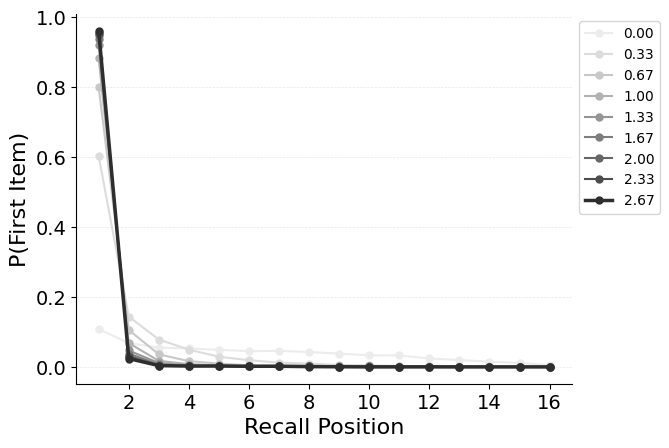

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdCMRDualCueNoStop_fixed_term_best_of_3_global_mcf_sensitivity_shift_spc.png)


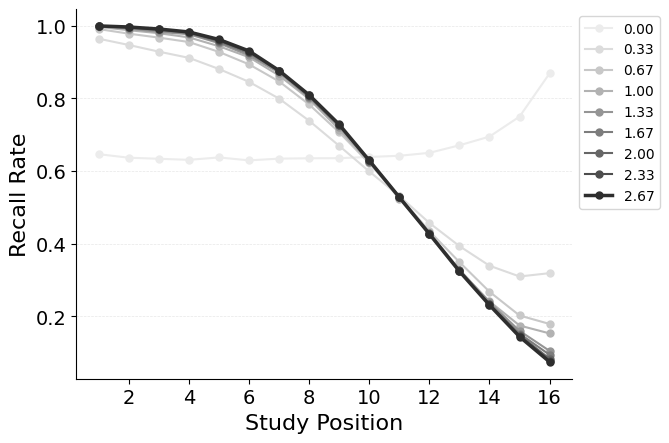

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdCMRDualCueNoStop_fixed_term_best_of_3_global_mcf_sensitivity_shift_crp.png)


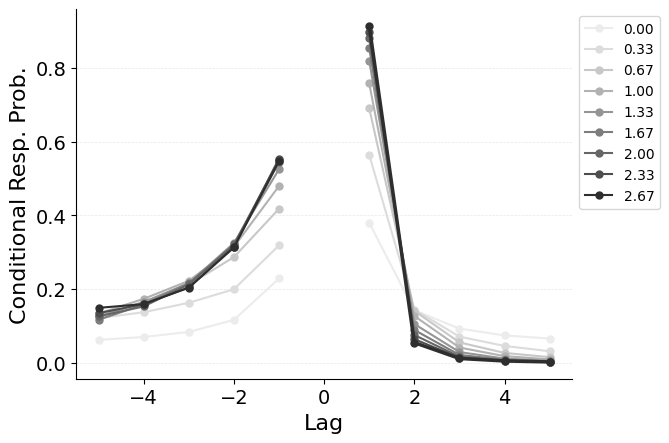

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdCMRDualCueNoStop_fixed_term_best_of_3_global_mcf_sensitivity_shift_pnr.png)


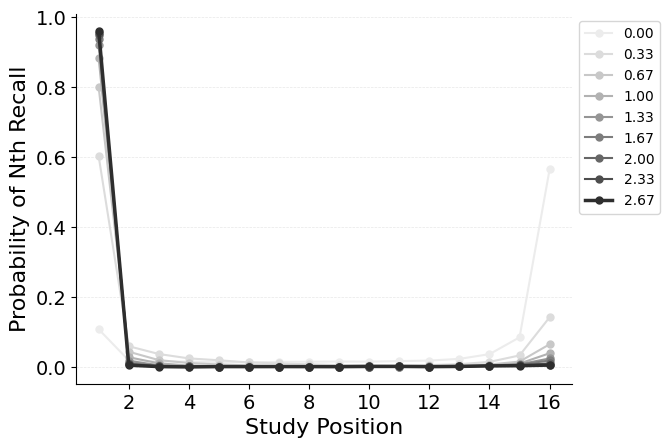

In [8]:
# | code-summary: parameter-shifted views

for analysis in comparison_analyses:
    figure_str = (
        f"{data_tag}_{model_name}_{run_tag}_{varied_parameter}_shift_{analysis.__name__[5:]}.png"
    )
    figure_path = os.path.join(product_dirs['figures'], figure_str)
    print(f"![]({figure_path})")

    # if os.path.exists(figure_path) and not redo_figures:
    #     display(Image(filename=figure_path))
    #     continue

    cmap = plt.get_cmap('Greys')
    n_vals = len(considered_values)
    eps = 0.15
    color_cycle = [cmap(x) for x in np.linspace(eps, 1 - eps, n_vals)]
    color_cycle = [mcolors.rgb2hex(c) for c in color_cycle]

    sim_trial_mask = generate_trial_mask(sim[0], trial_query)

    axis = analysis(
        datasets=sim,
        trial_masks=[sim_trial_mask] * len(considered_values),
        color_cycle=color_cycle,
        distances=1 - connections,
        axis=plt.gca(),
        labels=format_floats(considered_values, 2),
        contrast_name=varied_parameter,
    )
    axis.get_lines()[-1].set_linewidth(2.5)

    axis.tick_params(labelsize=14)
    axis.set_xlabel(axis.get_xlabel(), fontsize=16)
    axis.set_ylabel(axis.get_ylabel(), fontsize=16)
    axis.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.savefig(figure_path, bbox_inches='tight', dpi=600)
    plt.show()
